# Determining the Task Completion Rate threshold

The purpose of this notebook is to derive the maximum acceptable latency value used by the `task_completion_rate` (TCR) metric. As defined in `metrics_tracker.xlsx`, TCR is the percentage of tasks completed by the chatbot within a defined latency window — so its threshold is not a quality score (like Answer Relevancy or Faithfulness) but a latency cutoff, measured in seconds.

**Methodological note.** The other five metrics in IHAEF derive their thresholds from human annotation: the human pass rate sets the target, and the percentile method picks the score that splits the model's outputs at that same rate. TCR cannot follow this exact procedure, because latency is not a quality judgement — there is no "human annotation" of which response times are acceptable.

Instead, the threshold is derived from the **observed latency distribution** of the deployed system. The 95th percentile is selected as the threshold, with the following interpretation: *responses slower than 95% of typical responses are flagged as operational anomalies*. This keeps the methodology consistent with the other metrics in spirit — using empirical data rather than arbitrary numbers — while acknowledging that the underlying logic differs.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print

In [3]:
data = pd.read_csv('../data/evaluation_results_latency.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   conv_id                             21 non-null     object 
 1   user_input                          21 non-null     object 
 2   bot_output                          21 non-null     object 
 3   latency                             21 non-null     float64
 4   retrieval_context                   21 non-null     object 
 5   Answer Relevancy                    21 non-null     float64
 6   Answer Relevancy_reason             21 non-null     object 
 7   Faithfulness                        21 non-null     float64
 8   Faithfulness_reason                 21 non-null     object 
 9   Contextual Relevancy                21 non-null     float64
 10  Contextual Relevancy_reason         21 non-null     object 
 11  Tone Attunement [GEval]             21 non-null

In [4]:
data[['user_input', 'latency']].head()

,user_input,latency
0,I need a doctor.,4.209270
1,"I need help because I am in danger, but I do n...",3.605792
2,I don't have a place to stay because I escaped...,2.574120
3,"I am running away from my abuser, who is searc...",6.340913
4,"I have been to 3 hospitals, but they refuse me...",2.050503


## Inspecting the latency distribution

Before computing the threshold, we examine the shape of the distribution to confirm that a percentile-based approach is appropriate. The threshold logic assumes that latency values represent typical system performance. If the distribution were degenerate (e.g., all values clustered at one point, or dominated by outliers), the percentile method would not yield a meaningful cutoff.

In [5]:
latency = data['latency']
print(latency.describe())

count    21.000000
mean      4.480827
std       1.997064
min       1.980217
25%       2.574120
50%       4.613280
75%       5.848326
max       8.709196
Name: latency, dtype: float64

In [6]:
for p in [50, 75, 90, 95, 99]:
    print(f"p{p}: {np.percentile(latency, p):.3f}s")

p50: 4.613s

p75: 5.848s

p90: 6.880s

p95: 7.456s

p99: 8.459s

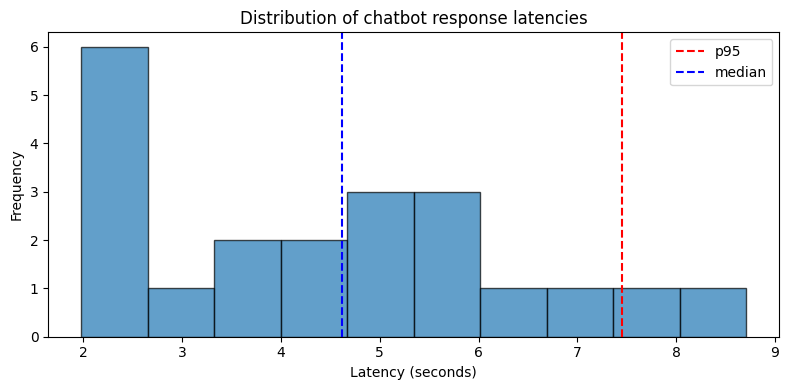

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(latency, bins=10, edgecolor='black', alpha=0.7)
ax.axvline(np.percentile(latency, 95), color='red', linestyle='--', label='p95')
ax.axvline(latency.median(), color='blue', linestyle='--', label='median')
ax.set_xlabel('Latency (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of chatbot response latencies')
ax.legend()
plt.tight_layout()
plt.show()

## Applying the percentile method

For the quality metrics, the percentile was set by the human pass rate. For TCR, the percentile is set directly — at the 95th percentile of observed latencies. The rationale: 95% of responses fall at or below this value during normal operation, so responses slower than this represent the slowest 5% of system behaviour and warrant flagging.

Using a higher percentile (p99) would only flag extreme outliers, which is too permissive for an operational metric. Using a lower percentile (p90 or below) would flag a substantial fraction of normal traffic and risk inflating the false-failure rate.

In [8]:
tcr_percentile = 95
tcr_threshold = np.percentile(latency, tcr_percentile)
print(f"TCR threshold at p{tcr_percentile}: {tcr_threshold:.2f}s")

TCR threshold at p95: 7.46s

In [9]:
# Sanity check: count how many responses would pass / fail at this threshold
passes = (latency <= tcr_threshold).sum()
fails = (latency > tcr_threshold).sum()
print(f"Pass (<= {tcr_threshold:.2f}s): {passes}/{len(latency)}")
print(f"Fail (> {tcr_threshold:.2f}s): {fails}/{len(latency)}")
print(f"Empirical pass rate: {passes / len(latency) * 100:.2f}%")

Pass (<= 7.46s): 20/21

Fail (> 7.46s): 1/21

Empirical pass rate: 95.24%

## Sanity check against UX literature

An empirical threshold should sit within ranges considered acceptable by the wider conversational-AI literature. The reference points used here:

- **Nielsen's response-time thresholds** (1993, still widely cited): 0.1s gives the feel of instantaneous response; 1.0s is the limit of uninterrupted flow of thought; 10s is the limit beyond which user attention is typically lost.
- **Conversational AI evaluation literature** (Langfuse, 2025; Mehta, 2025) treats single-digit-second response latencies as the expected range for text chatbots, with operational concern increasing past ~10s.
- **WhatsApp messaging context**: as an asynchronous channel, WhatsApp users tolerate slightly longer waits than synchronous web chat, but the chatbot is positioned as an alternative to a slower human helpline, so the operational pressure remains for sub-10s responses.

The derived threshold sits within these ranges, confirming the empirical value is not at odds with established UX expectations.

## Discussion and limitations

**Methodological limitation.** A percentile-of-distribution approach flags performance *worse than the system's typical behaviour*. It cannot, on its own, determine whether the typical behaviour is acceptable. For HIA this is not a concern: the maximum observed latency in this sample is well within single-digit-second ranges and below the 10-second user-attention threshold from UX literature. If the system as a whole were globally slow, the p95 value would simply represent "slow but typical" performance, and the metric would lose diagnostic value.

**Sample size.** The threshold is derived from N = 21 queries on Dataset A. A larger sample, particularly over real-world traffic patterns, would tighten the estimate. As deployment data accumulates, the threshold should be re-derived periodically rather than fixed once.

**Boundary with task completion.** TCR conflates two concepts: latency tolerance and successful task completion. In the current definition, a response is treated as "completed" if it arrives within the latency window, regardless of substantive content. Whether to retain this conflation or split TCR into separate latency and task-resolution metrics is a design question outside the scope of this notebook, but worth flagging for future refinement of IHAEF.